In [2]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *

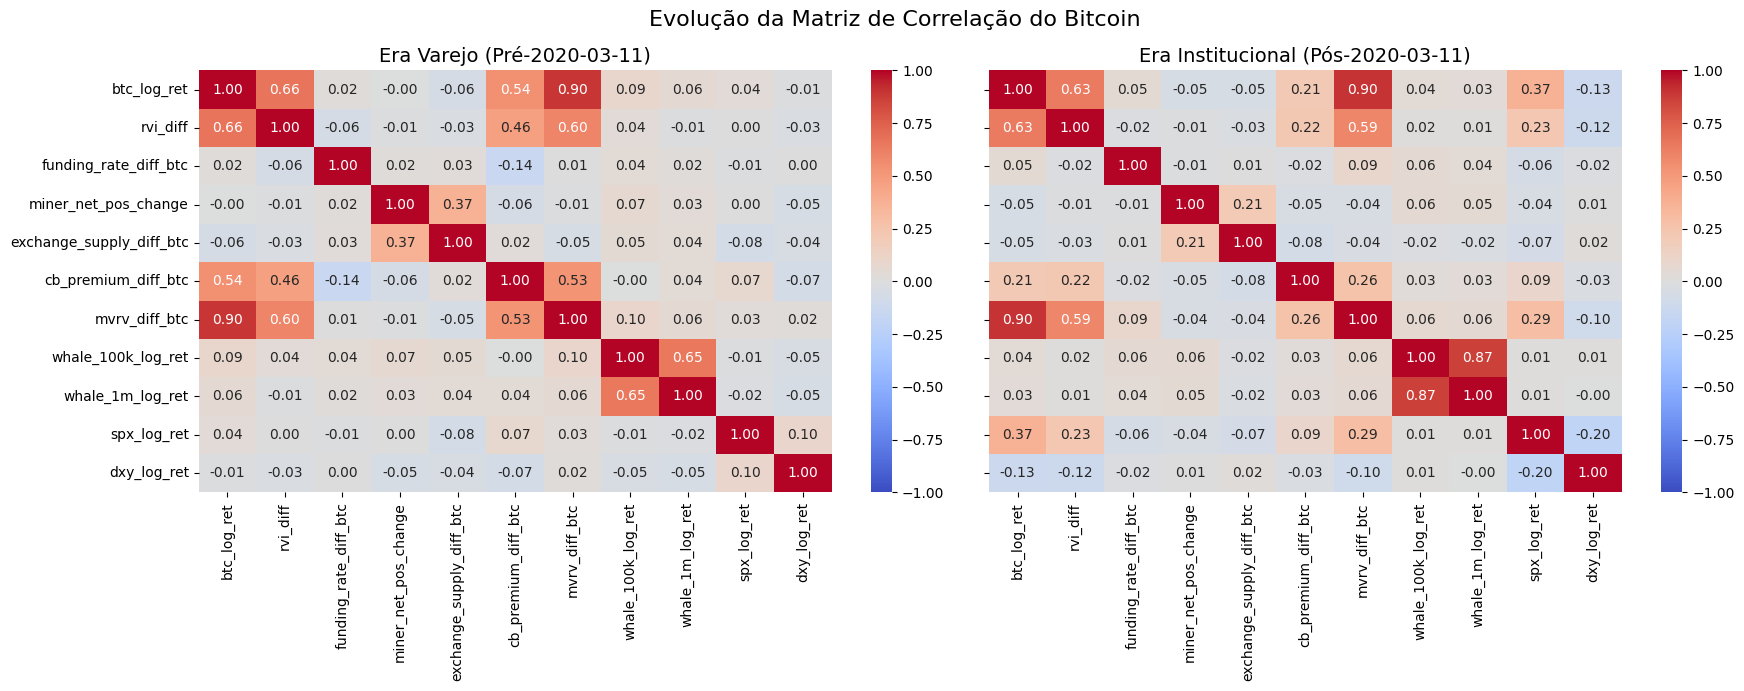

In [3]:
# ==============================================================================
# 3. MATRIZES DE CORRELAÇÃO COMPARATIVAS (Para a Seção 3.3)
# ==============================================================================

df_copy = df_features.copy()
df_copy = df_copy.set_index('Data_UTC')

# Selecionar variáveis TRANSFORMADAS (Stationary)
# Selecionar variáveis TRANSFORMADAS (Stationary)
cols_corr = ['btc_log_ret', 'rvi_diff','funding_rate_diff_btc', 'miner_net_pos_change','exchange_supply_diff_btc',
             'cb_premium_diff_btc','mvrv_diff_btc','whale_100k_log_ret','whale_1m_log_ret','spx_log_ret','dxy_log_ret',
             'nasdaq_log_ret','gold_log_ret','us10y_diff','vix_log_ret','total3_log_ret','ssr_diff','flippening_close_diff','social_vol_log_spread',
             'social_momentum','usdt_log_ret','usdc_log_ret']

# Dividir a lista em duas metades
mid_point = len(cols_corr) // 2
cols_corr1 = cols_corr[:mid_point]
cols_corr2 = cols_corr[mid_point:]

cols_corr = cols_corr1

# Dividir os dados
df_varejo = df_copy.loc[:DATA_DIVISAO_ERA][cols_corr]
df_institucional = df_copy.loc[DATA_DIVISAO_ERA:][cols_corr]
# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# Plotar Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})', fontsize=14)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})', fontsize=14)
plt.suptitle('Evolução da Matriz de Correlação do Bitcoin', fontsize=16)
plt.tight_layout()
plt.show()

# O que procurar aqui: Veja se o quadrado entre btc_Log_Ret e SPX_Log_Ret ficou "mais vermelho" no segundo gráfico. 
# Se sim, sua tese está provada visualmente.

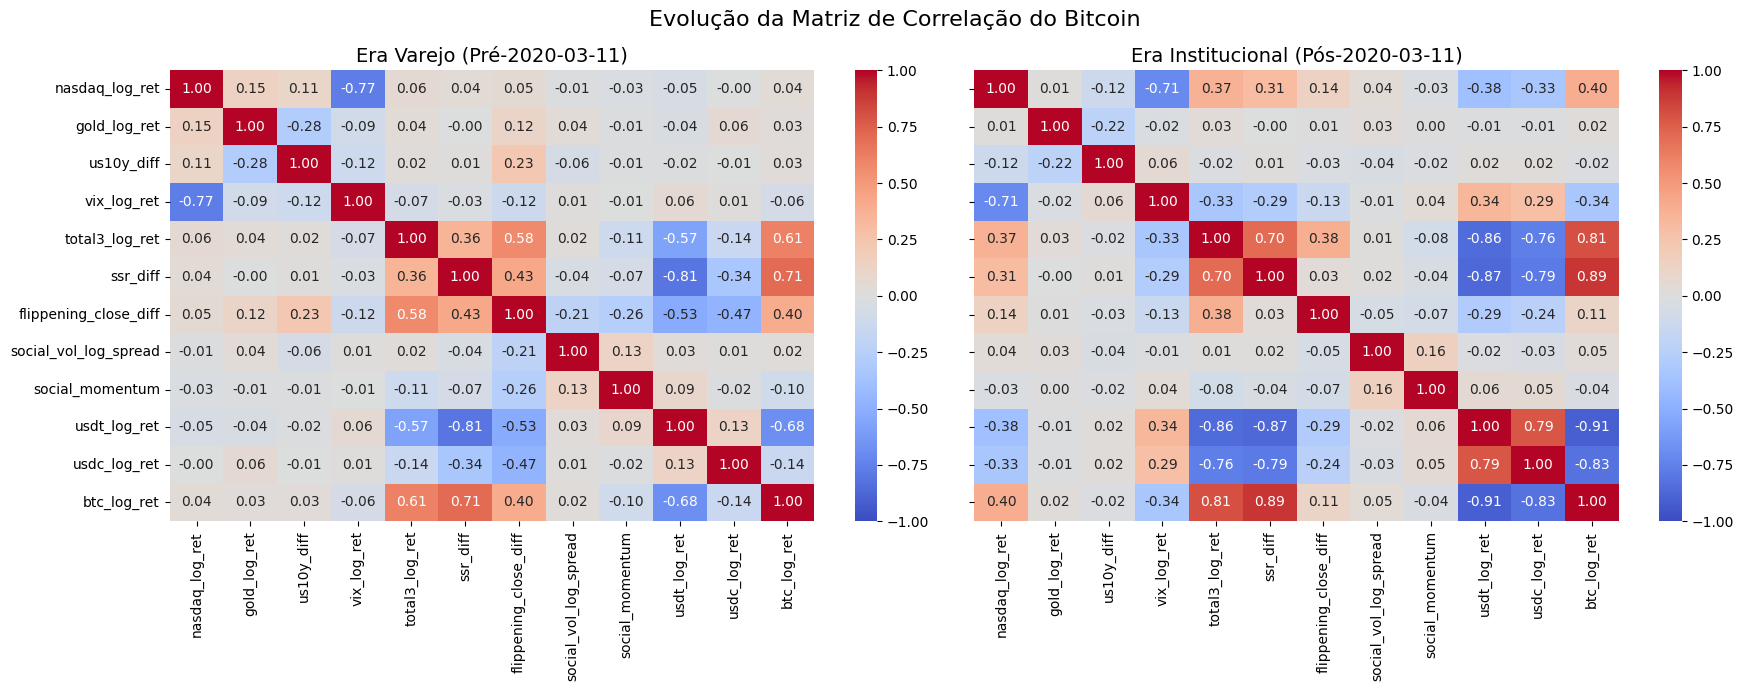

In [4]:
# ==============================================================================
# 3. MATRIZES DE CORRELAÇÃO COMPARATIVAS (Para a Seção 3.3)
# ==============================================================================

# Selecionar variáveis TRANSFORMADAS (Stationary)
# Selecionar variáveis TRANSFORMADAS (Stationary)
cols_corr = ['btc_log_ret', 'rvi_diff','funding_rate_diff_btc', 'miner_net_pos_change','exchange_supply_diff_btc',
             'cb_premium_diff_btc','mvrv_diff_btc','whale_100k_log_ret','whale_1m_log_ret','spx_log_ret','dxy_log_ret',
             'nasdaq_log_ret','gold_log_ret','us10y_diff','vix_log_ret','total3_log_ret','ssr_diff','flippening_close_diff','social_vol_log_spread',
             'social_momentum','usdt_log_ret','usdc_log_ret','btc_log_ret']

# Dividir a lista em duas metades
mid_point = len(cols_corr) // 2
cols_corr1 = cols_corr[:mid_point]
cols_corr2 = cols_corr[mid_point:]

cols_corr = cols_corr2

# Dividir os dados
df_varejo = df_copy.loc[:DATA_DIVISAO_ERA][cols_corr]
df_institucional = df_copy.loc[DATA_DIVISAO_ERA:][cols_corr]
# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# Plotar Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})', fontsize=14)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})', fontsize=14)
plt.suptitle('Evolução da Matriz de Correlação do Bitcoin', fontsize=16)
plt.tight_layout()
plt.show()

# O que procurar aqui: Veja se o quadrado entre btc_Log_Ret e SPX_Log_Ret ficou "mais vermelho" no segundo gráfico. 
# Se sim, sua tese está provada visualmente.

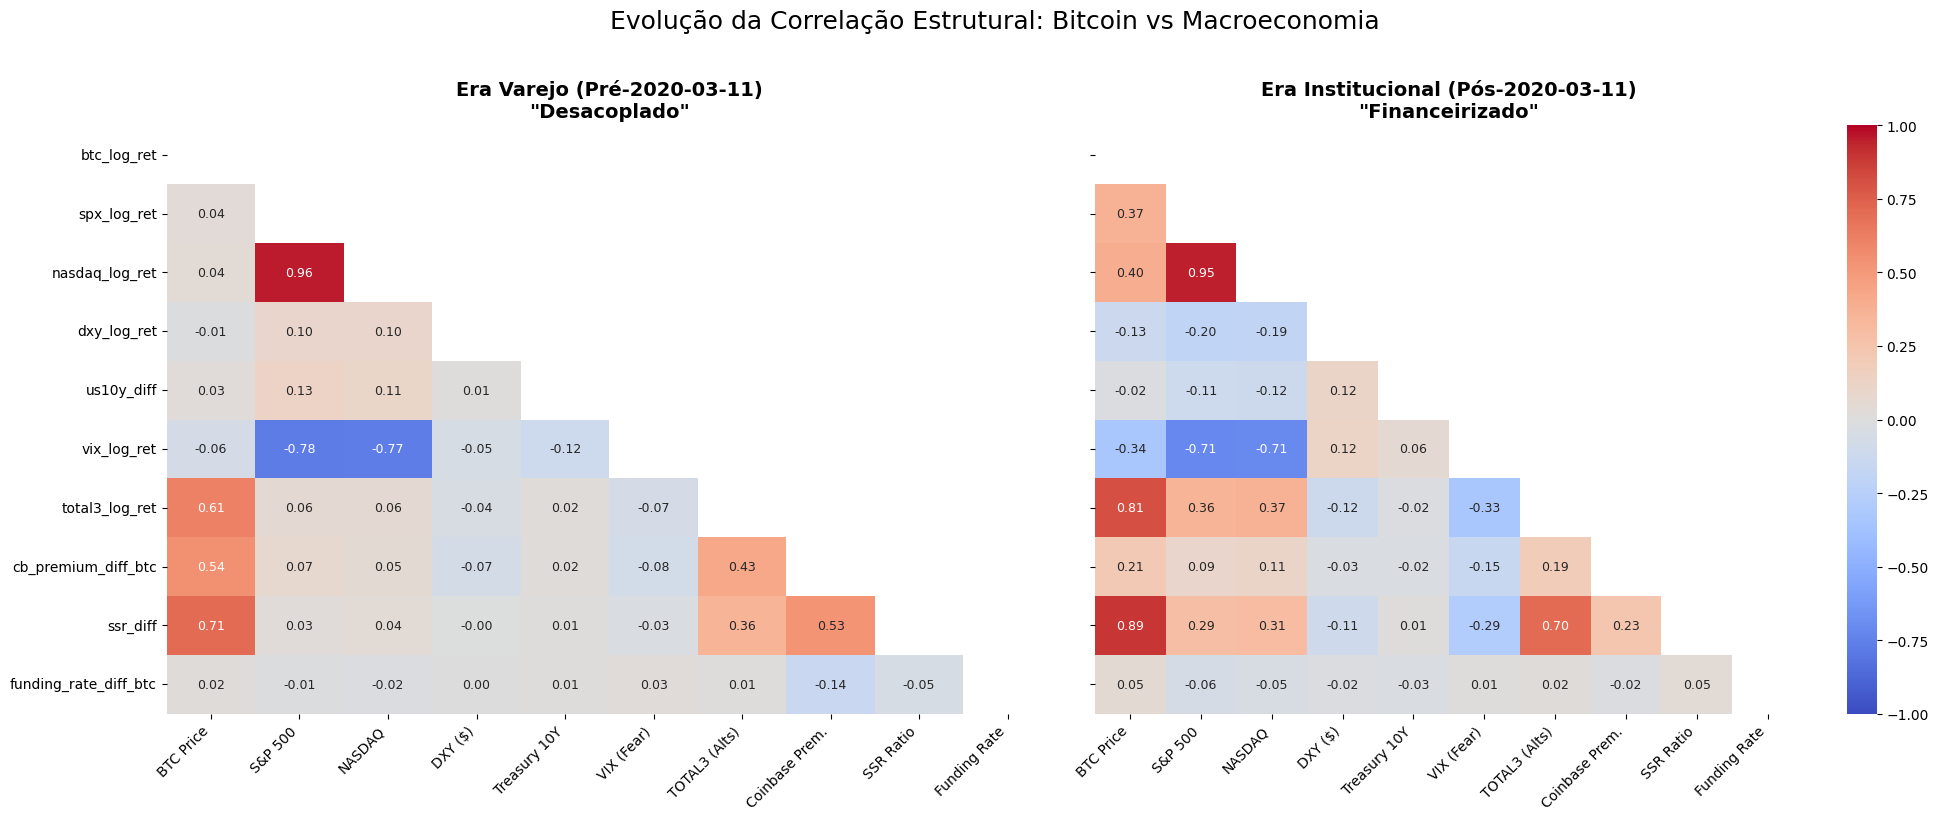

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# SELEÇÃO DO "DREAM TEAM" DE VARIÁVEIS
# ==============================================================================
# Selecionamos apenas as variáveis que validam a tese de Financeirização
# Target: btc_log_ret
cols_dream_team = [
    'btc_log_ret',              # O ALVO (Preço)
    'spx_log_ret',              # S&P 500 (Risco Global)
    'nasdaq_log_ret',              # NASDAQ (Setor Tech)
    'dxy_log_ret',            # Dólar (Liquidez Fiat)
    'us10y_diff',               # Juros (Custo de Oportunidade)
    'vix_log_ret',              # VIX (Medo)
    'total3_log_ret',           # Altcoins (Apetite de Risco Crypto)
    'cb_premium_diff_btc',      # Institucional (Coinbase)
    'ssr_diff',                 # Stablecoin Supply (Pólvora Seca)
    'funding_rate_diff_btc'     # Alavancagem Especulativa
]

# Títulos amigáveis para o Gráfico (Opcional, mas fica lindo no TCC)
labels_amigaveis = [
    'BTC Price', 'S&P 500', 'NASDAQ', 'DXY ($)', 'Treasury 10Y', 
    'VIX (Fear)', 'TOTAL3 (Alts)', 'Coinbase Prem.', 'SSR Ratio', 'Funding Rate'
]

# ==============================================================================
# PREPARAÇÃO DOS DADOS
# ==============================================================================
df_clean = df_copy[cols_dream_team].copy()

# Dividir os dados temporalmente
df_varejo = df_clean.loc[:DATA_DIVISAO_ERA]
df_institucional = df_clean.loc[DATA_DIVISAO_ERA:]
# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# ==============================================================================
# PLOTAGEM COM MÁSCARA (Visual Limpo)
# ==============================================================================

# Criar máscara para esconder o triângulo superior (evita informação duplicada)
mask_varejo = np.triu(np.ones_like(corr_varejo, dtype=bool))
mask_inst = np.triu(np.ones_like(corr_institucional, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], mask=mask_varejo, annot=True, 
            cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", 
            cbar=False, annot_kws={"size": 9})
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})\n"Desacoplado"', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(labels_amigaveis, rotation=45, ha='right')
axes[0].set_yticklabels(labels_amigaveis, rotation=0)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], mask=mask_inst, annot=True, 
            cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", 
            cbar=True, annot_kws={"size": 9})
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})\n"Financeirizado"', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(labels_amigaveis, rotation=45, ha='right')

plt.suptitle('Evolução da Correlação Estrutural: Bitcoin vs Macroeconomia', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()